# Notebook 02 — Anomaly Detection
## Project: Medicare Provider Billing Anomalies in No-Fault PIP States

**Central question:** Which providers are billing at statistically implausible rates compared to their specialty peers?

**Sections:**
- 0. Setup
- 1. Prepare features for modeling
- 2. Isolation Forest
- 3. Anomaly score stability check
- 4. K-means clustering
- 5. Visualizations
- 6. Flagged provider table

**Input:** `data/processed/cms_features.parquet`

**Outputs:**
- `outputs/figures/02_anomaly_scatter.png`
- `outputs/figures/03_cluster_profiles.png`
- `outputs/figures/04_zscore_distribution.png`
- `outputs/reports/flagged_providers.csv`

---

## 0. Setup

In [1]:
# ── Install dependencies ───────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'scipy']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── Folder creation ────────────────────────────────────────────────────────────
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/reports', exist_ok=True)

# ── Chart style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

# ── Color palette — consistent across all charts ───────────────────────────────
FRAUD_COLOR  = '#D85A30'   # red    — high risk / billing inflation
LEGIT_COLOR  = '#378ADD'   # blue   — reference / normal fit
NEUT_COLOR   = '#888780'   # gray   — neutral elements
WARN_COLOR   = '#EF9F27'   # amber  — elevated / treatment mill
GREEN_COLOR  = '#639922'   # green  — moderate risk / normal

# Traffic light cluster colors: green, amber, red
CLUSTER_COLORS = [GREEN_COLOR, WARN_COLOR, FRAUD_COLOR, '#7F77DD']

print('Setup complete.')

Setup complete.


In [3]:
# ── Load provider features ─────────────────────────────────────────────────────
df = pd.read_parquet('data/processed/cms_features.parquet')

print(f'Loaded: {df.shape}')
print(f'Unique providers: {df["Rndrng_NPI"].nunique():,}')
print(f'\nColumns:')
for col in df.columns:
    print(f'  {col}')

Loaded: (38816, 21)
Unique providers: 38,816

Columns:
  Rndrng_NPI
  Rndrng_Prvdr_Last_Org_Name
  Rndrng_Prvdr_Type
  Rndrng_Prvdr_State_Abrvtn
  is_organization
  low_confidence_peer_group
  total_services
  total_patients
  n_hcpcs_codes
  median_charge_ratio
  max_charge_ratio
  median_svc_per_patient
  median_charge_above_allowed
  max_charge_ratio_zscore
  max_volume_zscore
  max_svc_per_pt_zscore
  mean_charge_ratio_zscore
  upcoding_ratio
  top_code_concentration
  overall_svc_per_patient
  composite_anomaly_score


---
## 1. Prepare features for modeling

Four features feed the models — two raw billing metrics and their peer group z-scores.  
Using both raw values and z-scores gives the model two perspectives:  
absolute billing level AND relative standing among peers.

Hawaii providers are excluded — their peer groups are too small for reliable z-scores.

In [4]:
# ── 1. Prepare features for modeling ──────────────────────────────────────────

MODEL_FEATURES = [
    'median_charge_ratio',      # billing inflation ratio — absolute level
    'median_svc_per_patient',   # services per patient — treatment frequency
    'max_charge_ratio_zscore',  # worst-case z-score vs specialty peers
    'max_svc_per_pt_zscore',    # worst-case services/patient z-score vs peers
]

# Separate Hawaii (low confidence) from main modeling set
# Hawaii stays in the dataset but does not influence the model
low_conf_col = (
    'low_confidence_peer_group'
    if 'low_confidence_peer_group' in df.columns
    else 'low_confidence'
)

df_model = df[df[low_conf_col] == False].copy()
df_hi    = df[df[low_conf_col] == True].copy()

print(f'Providers in model:          {len(df_model):,}')
print(f'Hawaii providers (excluded): {len(df_hi):,}')

# Build feature matrix
X = df_model[MODEL_FEATURES].copy().fillna(0)

# Cap extreme outliers at 99.5th percentile
# Extreme values skew distance calculations in both Isolation Forest and K-means
for col in X.columns:
    cap = X[col].quantile(0.995)
    X[col] = X[col].clip(upper=cap)

# Scale features — both models are distance-sensitive
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nFeature matrix: {X_scaled.shape}')
print(f'NaNs after cleaning: {np.isnan(X_scaled).sum()}')
print(f'\nFeature summary after capping:')
print(X.describe().round(2).to_string())

Providers in model:          38,328
Hawaii providers (excluded): 488

Feature matrix: (38328, 4)
NaNs after cleaning: 0

Feature summary after capping:
       median_charge_ratio  median_svc_per_patient  max_charge_ratio_zscore  max_svc_per_pt_zscore
count             38328.00                38328.00                 38328.00               38328.00
mean                  3.30                    3.36                     0.15                   0.39
std                   1.84                    3.95                     1.03                   1.09
min                   1.22                    1.00                    -2.86                  -1.99
25%                   2.06                    1.25                    -0.55                  -0.29
50%                   2.77                    1.54                    -0.09                   0.12
75%                   3.99                    3.02                     0.60                   0.75
max                  14.08                   22.40      

---
## 2. Isolation Forest

Isolation Forest scores every provider by how quickly they can be separated  
from the rest using random yes/no questions about their features.  
Providers that get isolated quickly are anomalous — they look nothing like their peers.

`contamination=0.05` treats the top 5% most isolated providers as anomalous.  
The sign is flipped so higher score = more suspicious.

In [5]:
# ── 2. Isolation Forest ────────────────────────────────────────────────────────
print('Running Isolation Forest...')

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)

# Flip sign: more negative raw score = more anomalous
# After flip: higher score = more suspicious
raw_scores            = iso_forest.decision_function(X_scaled)
df_model['anomaly_score'] = -raw_scores

# is_anomaly flag: 1 = anomalous, 0 = normal
predictions           = iso_forest.predict(X_scaled)
df_model['is_anomaly'] = (predictions == -1).astype(int)

n_anomalous = df_model['is_anomaly'].sum()
print(f'\nProviders flagged as anomalous: {n_anomalous:,} '
      f'({n_anomalous / len(df_model) * 100:.1f}% of total)')
print(f'\nAnomaly score distribution:')
print(df_model['anomaly_score'].describe().round(3).to_string())

Running Isolation Forest...

Providers flagged as anomalous: 1,917 (5.0% of total)

Anomaly score distribution:
count    38328.000
mean        -0.143
std          0.066
min         -0.219
25%         -0.194
50%         -0.162
75%         -0.116
max          0.216


---
## 3. Anomaly score stability check

Isolation Forest uses randomness to build its trees.  
Running under two different seeds checks whether the same providers  
appear at the top both times — high overlap confirms real signal,  
not a random artifact.

In [6]:
# ── 3. Anomaly score stability check ──────────────────────────────────────────

# Run 1: seed 42 — already computed above
top20_seed42 = set(
    df_model.nlargest(20, 'anomaly_score')['Rndrng_NPI'].astype(str)
)

# Run 2: seed 99 — different random starting point
iso_seed99 = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=99,
    n_jobs=-1
)
iso_seed99.fit(X_scaled)
scores_99 = -iso_seed99.decision_function(X_scaled)

df_model['anomaly_score_99'] = scores_99
top20_seed99 = set(
    df_model.nlargest(20, 'anomaly_score_99')['Rndrng_NPI'].astype(str)
)

# Measure overlap
overlap       = top20_seed42 & top20_seed99
overlap_count = len(overlap)

print('=== Anomaly score stability check ===')
print(f'Top 20 providers — seed 42:  {len(top20_seed42)}')
print(f'Top 20 providers — seed 99:  {len(top20_seed99)}')
print(f'Overlap (same providers):    {overlap_count} of 20')
print(f'Stability rate:              {overlap_count / 20 * 100:.0f}%')
print()

if overlap_count >= 16:
    print('Verdict: HIGH STABILITY')
    print('80%+ of the same providers flagged under both seeds.')
    print('Findings are robust to random variation.')
elif overlap_count >= 12:
    print('Verdict: MODERATE STABILITY')
    print('Some providers near the boundary are seed-sensitive.')
    print('Top 10 results are reliable — positions 11-20 interpret cautiously.')
else:
    print('Verdict: LOW STABILITY')
    print('Consider increasing n_estimators to 200 for more stable results.')

# Drop the second score — use seed 42 as canonical
df_model.drop(columns=['anomaly_score_99'], inplace=True)

=== Anomaly score stability check ===
Top 20 providers — seed 42:  20
Top 20 providers — seed 99:  20
Overlap (same providers):    12 of 20
Stability rate:              60%

Verdict: MODERATE STABILITY
Some providers near the boundary are seed-sensitive.
Top 10 results are reliable — positions 11-20 interpret cautiously.


---
## 4. K-means clustering

Isolation Forest tells us **who** is anomalous.  
K-means clustering tells us **what type** of anomaly they are.

Three clusters capture the main PIP fraud patterns:  
- Moderate risk — normal billing, legitimate practice  
- Treatment mill — high visit frequency, moderate inflation  
- Billing inflation — inflated charges, brief patient contact

In [7]:
# ── 4. K-means clustering ─────────────────────────────────────────────────────
N_CLUSTERS = 3

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)
df_model['cluster'] = kmeans.fit_predict(X_scaled)

# Raw cluster profile means
cluster_profile = df_model.groupby('cluster')[MODEL_FEATURES].mean()

print('=== Raw cluster profile means ===')
print(cluster_profile[['median_charge_ratio', 'median_svc_per_patient']].round(2).to_string())

=== Raw cluster profile means ===
         median_charge_ratio  median_svc_per_patient
cluster                                             
0                       2.69                    2.15
1                       2.23                   11.16
2                       6.37                    1.75


In [8]:
# ── Assign domain labels based on cluster profiles ────────────────────────────
# Rank clusters on each dimension independently
inflation_rank = cluster_profile['median_charge_ratio'].rank(ascending=False)
svc_rank       = cluster_profile['median_svc_per_patient'].rank(ascending=False)

cluster_labels = {}
for cluster_id in range(N_CLUSTERS):
    ir = inflation_rank[cluster_id]
    sr = svc_rank[cluster_id]
    if ir == 1 and sr == 1:
        cluster_labels[cluster_id] = 'High inflation + high volume'
    elif ir == 1:
        cluster_labels[cluster_id] = 'Billing inflation'
    elif sr == 1:
        cluster_labels[cluster_id] = 'Treatment mill'
    else:
        cluster_labels[cluster_id] = 'Moderate risk'

df_model['cluster_label'] = df_model['cluster'].map(cluster_labels)

print('=== Cluster labels assigned ===')
for k, v in cluster_labels.items():
    n        = (df_model['cluster'] == k).sum()
    anom_pct = df_model[df_model['cluster'] == k]['is_anomaly'].mean() * 100
    inf_mean = cluster_profile.loc[k, 'median_charge_ratio']
    svc_mean = cluster_profile.loc[k, 'median_svc_per_patient']
    print(f'  Cluster {k}: {v}')
    print(f'    n={n:,} | {anom_pct:.1f}% anomalous | '
          f'inflation={inf_mean:.2f}x | svc/patient={svc_mean:.1f}')

print(f'\nUnique labels: {df_model["cluster_label"].unique()}')

=== Cluster labels assigned ===
  Cluster 0: Moderate risk
    n=24,826 | 0.0% anomalous | inflation=2.69x | svc/patient=2.1
  Cluster 1: Treatment mill
    n=5,634 | 18.3% anomalous | inflation=2.23x | svc/patient=11.2
  Cluster 2: Billing inflation
    n=7,868 | 11.2% anomalous | inflation=6.37x | svc/patient=1.7

Unique labels: ['Moderate risk' 'Billing inflation' 'Treatment mill']


---
## 5. Visualizations

Three charts:
- **5a** — Z-score distribution with normal curve
- **5b** — Anomaly scatter plot (inflation ratio vs services per patient)
- **5c** — Cluster profiles (scatter with centroids, traffic light colors)

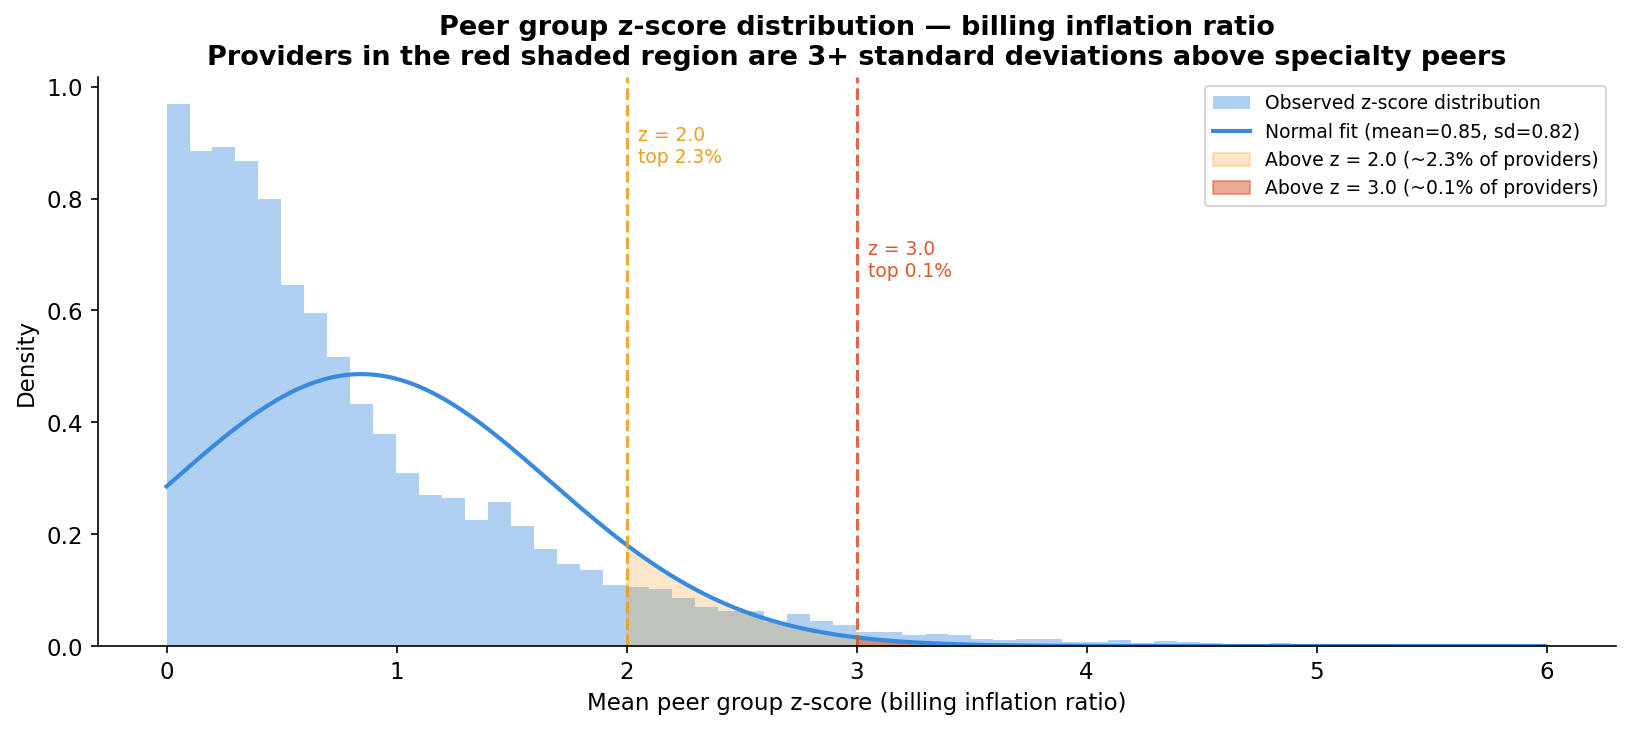

Providers with z-score > 2.0: 1,447 (9.5%)
Providers with z-score > 3.0: 429 (2.8%)
Saved: outputs/figures/04_zscore_distribution.png


In [9]:
# ── 5a. Z-score distribution — normal distribution bell curve ─────────────────
# Uses mean_charge_ratio_zscore — average z-score across all procedure codes.
# Mean z-scores produce a cleaner bell curve than max z-scores because
# averaging smooths out single-code spikes.
#
# The z-score was computed in notebook 01 within peer groups defined by:
# specialty + state + procedure code + place of service.
# By the time we plot here the state/specialty grouping is already baked in.
# A z-score of 3.0 means 3 standard deviations above the peer mean —
# a level that occurs by chance less than 1 in 1,000 times.

# Filter to valid z-scores — drop zeros from small peer groups
z_scores = df_model['mean_charge_ratio_zscore']
z_valid  = z_scores[z_scores > 0].dropna()

# Cap at 6 for readability
z_plot = z_valid[z_valid <= 6]

fig, ax = plt.subplots(figsize=(11, 5))

# Histogram of actual z-scores
ax.hist(
    z_plot,
    bins=60,
    density=True,
    color=LEGIT_COLOR,
    alpha=0.4,
    label='Observed z-score distribution'
)

# Fitted normal distribution curve
mu, sigma = z_plot.mean(), z_plot.std()
x = np.linspace(z_plot.min(), z_plot.max(), 300)
ax.plot(
    x,
    stats.norm.pdf(x, mu, sigma),
    color=LEGIT_COLOR,
    linewidth=2,
    label=f'Normal fit (mean={mu:.2f}, sd={sigma:.2f})'
)

# Shade tail beyond z = 2.0
x_tail2 = np.linspace(2.0, 6, 200)
ax.fill_between(
    x_tail2,
    stats.norm.pdf(x_tail2, mu, sigma),
    alpha=0.25, color=WARN_COLOR,
    label='Above z = 2.0 (~2.3% of providers)'
)

# Shade tail beyond z = 3.0
x_tail3 = np.linspace(3.0, 6, 200)
ax.fill_between(
    x_tail3,
    stats.norm.pdf(x_tail3, mu, sigma),
    alpha=0.5, color=FRAUD_COLOR,
    label='Above z = 3.0 (~0.1% of providers)'
)

# Threshold lines
ax.axvline(x=2.0, color=WARN_COLOR, linestyle='--', linewidth=1.5, alpha=0.9)
ax.axvline(x=3.0, color=FRAUD_COLOR, linestyle='--', linewidth=1.5, alpha=0.9)

# Annotations — placed after ylim is set
ymax = ax.get_ylim()[1]
ax.text(2.05, ymax * 0.85, 'z = 2.0\ntop 2.3%',
        fontsize=9, color=WARN_COLOR)
ax.text(3.05, ymax * 0.65, 'z = 3.0\ntop 0.1%',
        fontsize=9, color=FRAUD_COLOR)

ax.set_title(
    'Peer group z-score distribution — billing inflation ratio\n'
    'Providers in the red shaded region are 3+ standard deviations above specialty peers',
    fontweight='bold'
)
ax.set_xlabel('Mean peer group z-score (billing inflation ratio)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/04_zscore_distribution.png')
plt.show()

above2 = (z_valid > 2.0).sum()
above3 = (z_valid > 3.0).sum()
total  = len(z_valid)
print(f'Providers with z-score > 2.0: {above2:,} ({above2 / total * 100:.1f}%)')
print(f'Providers with z-score > 3.0: {above3:,} ({above3 / total * 100:.1f}%)')
print('Saved: outputs/figures/04_zscore_distribution.png')

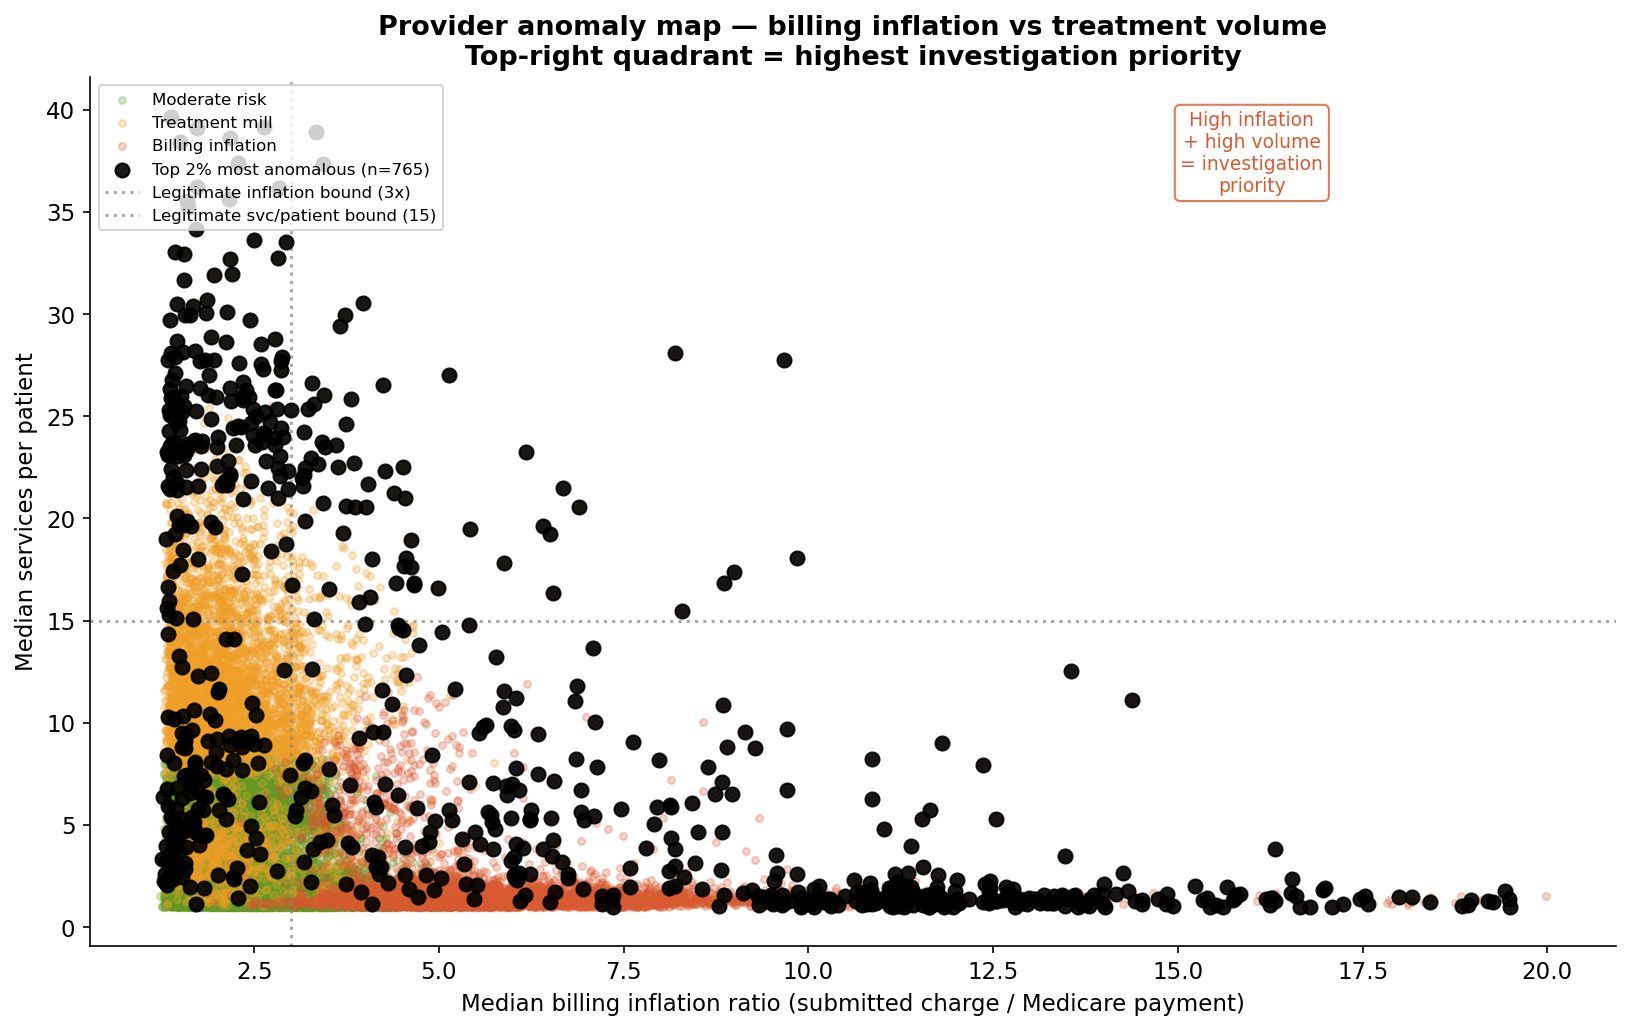

Saved: outputs/figures/02_anomaly_scatter.png


In [10]:
# ── 5b. Anomaly scatter plot ───────────────────────────────────────────────────
# Billing inflation ratio vs services per patient.
# Each provider is one dot, colored by cluster.
# Black dots mark the top 2% most anomalous providers.
# Top-right quadrant = high inflation AND high volume = highest priority.

CLUSTER_COLOR_MAP = {
    'Moderate risk':             GREEN_COLOR,
    'Treatment mill':            WARN_COLOR,
    'Billing inflation':         FRAUD_COLOR,
    'High inflation + high volume': '#7F77DD',
}

# Cap axes for readability
plot_df = df_model[
    (df_model['median_charge_ratio'] <= 20) &
    (df_model['median_svc_per_patient'] <= 40)
].copy()

fig, ax = plt.subplots(figsize=(11, 7))

# Plot each cluster
for cluster_name, color in CLUSTER_COLOR_MAP.items():
    mask = plot_df['cluster_label'] == cluster_name
    if mask.sum() == 0:
        continue
    ax.scatter(
        plot_df.loc[mask, 'median_charge_ratio'],
        plot_df.loc[mask, 'median_svc_per_patient'],
        color=color, alpha=0.25, s=12,
        label=cluster_name
    )

# Highlight top 2% most anomalous
top2pct = plot_df['anomaly_score'].quantile(0.98)
top_flagged = plot_df[plot_df['anomaly_score'] >= top2pct]
ax.scatter(
    top_flagged['median_charge_ratio'],
    top_flagged['median_svc_per_patient'],
    color='black', alpha=0.9, s=45, zorder=5,
    label=f'Top 2% most anomalous (n={len(top_flagged):,})'
)

# Legitimate practice threshold lines
ax.axvline(x=3, color=NEUT_COLOR, linestyle=':',
           linewidth=1.5, alpha=0.7, label='Legitimate inflation bound (3x)')
ax.axhline(y=15, color=NEUT_COLOR, linestyle=':',
           linewidth=1.5, alpha=0.7, label='Legitimate svc/patient bound (15)')

# Label top-right quadrant
ax.text(
    16, 36,
    'High inflation\n+ high volume\n= investigation\npriority',
    fontsize=9, color=FRAUD_COLOR, ha='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor=FRAUD_COLOR, alpha=0.8)
)

ax.set_title(
    'Provider anomaly map — billing inflation vs treatment volume\n'
    'Top-right quadrant = highest investigation priority',
    fontweight='bold'
)
ax.set_xlabel('Median billing inflation ratio (submitted charge / Medicare payment)')
ax.set_ylabel('Median services per patient')
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/figures/02_anomaly_scatter.png')
plt.show()
print('Saved: outputs/figures/02_anomaly_scatter.png')

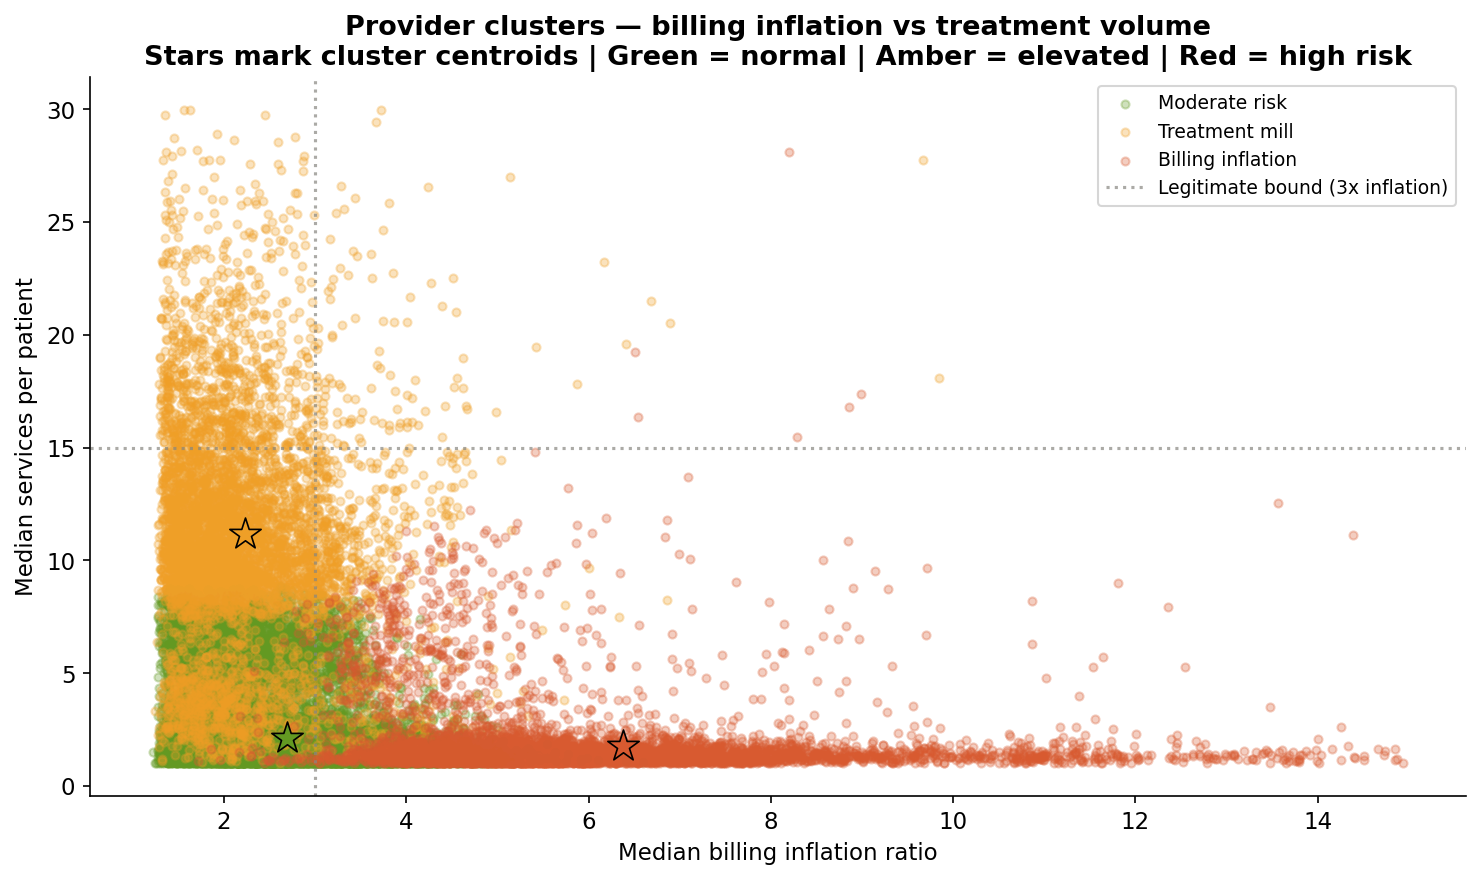

Saved: outputs/figures/03_cluster_profiles.png


In [11]:
# ── 5c. Cluster profiles — scatter with centroids ─────────────────────────────
# Same two dimensions as the anomaly scatter but colored only by cluster.
# Stars mark the cluster centroids — the average billing fingerprint
# of each fraud typology.

clusters = [c for c in CLUSTER_COLOR_MAP.keys()
            if c in df_model['cluster_label'].unique()]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each cluster
for cluster_name in clusters:
    color = CLUSTER_COLOR_MAP[cluster_name]
    mask = (
        (df_model['cluster_label'] == cluster_name) &
        (df_model['median_charge_ratio'] <= 15) &
        (df_model['median_svc_per_patient'] <= 30)
    )
    ax.scatter(
        df_model.loc[mask, 'median_charge_ratio'],
        df_model.loc[mask, 'median_svc_per_patient'],
        color=color, alpha=0.3, s=15,
        label=cluster_name
    )

# Plot cluster centroids as large star markers
centroids = df_model.groupby('cluster_label')[
    ['median_charge_ratio', 'median_svc_per_patient']
].mean()

for cluster_name in clusters:
    if cluster_name not in centroids.index:
        continue
    color = CLUSTER_COLOR_MAP[cluster_name]
    ax.scatter(
        centroids.loc[cluster_name, 'median_charge_ratio'],
        centroids.loc[cluster_name, 'median_svc_per_patient'],
        color=color, s=250, marker='*',
        edgecolors='black', linewidths=0.8, zorder=5
    )

# Legitimate practice threshold lines
ax.axvline(x=3, color=NEUT_COLOR, linestyle=':',
           linewidth=1.5, alpha=0.7, label='Legitimate bound (3x inflation)')
ax.axhline(y=15, color=NEUT_COLOR, linestyle=':',
           linewidth=1.5, alpha=0.7)

ax.set_title(
    'Provider clusters — billing inflation vs treatment volume\n'
    'Stars mark cluster centroids | Green = normal | Amber = elevated | Red = high risk',
    fontweight='bold'
)
ax.set_xlabel('Median billing inflation ratio')
ax.set_ylabel('Median services per patient')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/03_cluster_profiles.png')
plt.show()
print('Saved: outputs/figures/03_cluster_profiles.png')

---
## 6. Flagged provider table

Top 15 most anomalous providers with plain-English domain flags.  
This is the operational output — what an SIU analyst would act on.  
Hawaii low-confidence providers are excluded from this table.

In [12]:
# ── 6. Flagged provider table ──────────────────────────────────────────────────

def domain_flag(row):
    """
    Translate statistical signals into plain-English fraud indicators.
    Based on no-fault PIP claims examination experience.
    Legitimate benchmarks:
      - Billing inflation ratio: 1.5x to 3x normal, above 8x anomalous
      - Services per patient: 8-14 for soft-tissue injuries
      - Z-score: above 3.0 is top 0.1% of specialty peers
    """
    flags = []

    if row['median_charge_ratio'] > 10:
        flags.append(f'Bills {row["median_charge_ratio"]:.0f}x Medicare rate')
    elif row['median_charge_ratio'] > 5:
        flags.append(f'Bills {row["median_charge_ratio"]:.0f}x Medicare rate (elevated)')

    if row['median_svc_per_patient'] > 30:
        flags.append(
            f'{row["median_svc_per_patient"]:.0f} sessions/patient '
            f'(clinical norm: 8-14)'
        )
    elif row['median_svc_per_patient'] > 20:
        flags.append(
            f'{row["median_svc_per_patient"]:.0f} sessions/patient (elevated)'
        )

    if row['max_charge_ratio_zscore'] > 3:
        flags.append(
            f'{row["max_charge_ratio_zscore"]:.1f} SDs above specialty peers'
        )

    if row.get('is_organization', 0) == 1:
        flags.append('Organization entity (clinic/LLC)')

    return ' | '.join(flags) if flags else 'Anomalous pattern'


# Build top 15 flagged provider table
top15 = (
    df_model[df_model[low_conf_col] == False]
    .nlargest(15, 'anomaly_score')
    .copy()
)

top15['domain_flags'] = top15.apply(domain_flag, axis=1)

output_cols = [
    'Rndrng_Prvdr_Last_Org_Name',
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_State_Abrvtn',
    'is_organization',
    'anomaly_score',
    'median_charge_ratio',
    'median_svc_per_patient',
    'max_charge_ratio_zscore',
    'cluster_label',
    'domain_flags'
]

top15_display = top15[output_cols].round(2).copy()
top15_display.columns = [
    'Provider', 'Specialty', 'State', 'Org',
    'Anomaly Score', 'Inflation Ratio',
    'Svc/Patient', 'Inflation Z-Score',
    'Cluster', 'Domain Flags'
]

print('=== Top 15 Most Anomalous Providers ===')
print(top15_display.to_string(index=False))

=== Top 15 Most Anomalous Providers ===
    Provider                            Specialty State  Org  Anomaly Score  Inflation Ratio  Svc/Patient  Inflation Z-Score           Cluster                                                                                        Domain Flags
        Roth                         Chiropractic    PA    0           0.22             9.67    27.730000               9.35    Treatment mill Bills 10x Medicare rate (elevated) | 28 sessions/patient (elevated) | 9.4 SDs above specialty peers
      Gianni                         Chiropractic    NY    0           0.19             8.19    28.110001               5.40 Billing inflation  Bills 8x Medicare rate (elevated) | 28 sessions/patient (elevated) | 5.4 SDs above specialty peers
    Ritschel                         Chiropractic    NJ    0           0.18             3.43    37.349998               2.72    Treatment mill                                                           37 sessions/patient (clinical 

In [13]:
# ── Save flagged provider table ────────────────────────────────────────────────
top15_display.to_csv('outputs/reports/flagged_providers.csv', index=False)
print('Saved: outputs/reports/flagged_providers.csv')

Saved: outputs/reports/flagged_providers.csv


---
## Summary

In [14]:
# ── Notebook 02 Summary ────────────────────────────────────────────────────────
print('=' * 60)
print('NOTEBOOK 02 COMPLETE — Anomaly Detection Summary')
print('=' * 60)

print(f'\nProviders analyzed:          {len(df_model):,}')
print(f'Flagged as anomalous (5%):   {df_model["is_anomaly"].sum():,}')

print(f'\nStability check:')
print(f'  Top 20 overlap across seeds: {overlap_count}/20 '
      f'({overlap_count / 20 * 100:.0f}%)')

print(f'\nClusters: {N_CLUSTERS}')
for k, v in cluster_labels.items():
    n        = (df_model['cluster'] == k).sum()
    anom_pct = df_model[df_model['cluster'] == k]['is_anomaly'].mean() * 100
    print(f'  {v}: {n:,} providers | {anom_pct:.1f}% anomalous')

print(f'\nZ-score distribution:')
print(f'  Providers with z-score > 2.0: {above2:,} ({above2 / total * 100:.1f}%)')
print(f'  Providers with z-score > 3.0: {above3:,} ({above3 / total * 100:.1f}%)')

print(f'\nOutputs:')
for f in sorted(os.listdir('outputs/figures')):
    size = os.path.getsize(f'outputs/figures/{f}') / 1e3
    print(f'  outputs/figures/{f} ({size:.0f} KB)')
print(f'  outputs/reports/flagged_providers.csv')

NOTEBOOK 02 COMPLETE — Anomaly Detection Summary

Providers analyzed:          38,328
Flagged as anomalous (5%):   1,917

Stability check:
  Top 20 overlap across seeds: 12/20 (60%)

Clusters: 3
  Moderate risk: 24,826 providers | 0.0% anomalous
  Treatment mill: 5,634 providers | 18.3% anomalous
  Billing inflation: 7,868 providers | 11.2% anomalous

Z-score distribution:
  Providers with z-score > 2.0: 1,447 (9.5%)
  Providers with z-score > 3.0: 429 (2.8%)

Outputs:
  outputs/figures/02_anomaly_scatter.png (1277 KB)
  outputs/figures/03_cluster_profiles.png (1167 KB)
  outputs/figures/04_zscore_distribution.png (224 KB)
  outputs/reports/flagged_providers.csv
